# Near-Duplicate Audit — Is the Test Set Genuinely Held Out?
### Dataset: CICIDS-2017  ·  Runs on **Kaggle**

## The question

Our models score ~0.97 macro-F1 / ~0.997 binary F1. Earlier checks ruled out a harness leak
(negative controls) and port memorisation (ablation). One suspect remains: **near-duplicate
overlap**.

We removed *exact* duplicates before splitting. But network flows from the **same attack
burst** occur close together and are nearly identical in their features. A *random* train/test
split can therefore put near-twin flows into both sets — so a 'test' flow is one the model
essentially already saw in training. That inflates the score without being an outright bug.

## The test

For every **test** row, find its **nearest neighbour in the training set** (Euclidean distance
on the 47 scaled features) and record that distance. Then ask two questions:

1. **How close are test rows to training data?** Many distances ≈ 0 ⇒ heavy near-duplicate
   overlap. Healthy distances ⇒ a genuinely held-out test set.
2. **Does the model only succeed on rows it has a near-twin for?** We bucket test rows by
   nearest-neighbour distance and measure accuracy per bucket. If accuracy is high *only* for
   the near-zero-distance bucket and drops off for far rows, the score is memorisation. If
   accuracy stays high across *all* distance buckets, the model genuinely generalises.

**Interpretation guide**

| Pattern | Meaning |
|---|---|
| Few near-zero distances + flat accuracy-vs-distance | Test set is honestly held out; the 0.97 is real |
| Many near-zero distances + accuracy collapses with distance | Near-duplicate leakage inflates the score |

**Kaggle setup:** attach the FeatureSelection output dataset; set `IN_DIR`. No GPU needed.

## 1. Imports & Config

In [1]:
import os, json, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi']=110; plt.rcParams['savefig.bbox']='tight'

RANDOM_SEED=42; np.random.seed(RANDOM_SEED)
CLASS_NAMES=['BENIGN','Bot/Infiltration','Brute Force','DDoS','DoS','PortScan','Web Attack']
N_CLASSES=len(CLASS_NAMES)

IN_DIR='/kaggle/input/datasets/hanzlahmunir/fs-output'   # EDIT to your FeatureSelection mount path
OUT_DIR='/kaggle/working'; FIGURES_DIR=os.path.join(OUT_DIR,'figures'); os.makedirs(FIGURES_DIR,exist_ok=True)

_report=[]
def _log(t=''): _report.append(str(t)); print(t)
def _savefig(n,fig=None): p=os.path.join(FIGURES_DIR,n); (fig or plt).savefig(p,dpi=130,bbox_inches='tight'); return p
def write_report():
    p=os.path.join(OUT_DIR,'Audit_NearDuplicate_Report.txt')
    open(p,'w',encoding='utf-8').write('\n'.join(_report)); print('Report ->',p)

_log('='*70); _log('NEAR-DUPLICATE AUDIT  —  CICIDS-2017')
_log(f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}'); _log('='*70)
print('Setup complete.')

NEAR-DUPLICATE AUDIT  —  CICIDS-2017
Generated : 2026-05-22 20:56
Setup complete.


## 2. Load Data

In [2]:
train_path=os.path.join(IN_DIR,'train_selected.parquet')
test_path =os.path.join(IN_DIR,'test_selected.parquet')
feat_path =os.path.join(IN_DIR,'selected_features.json')
for p in [train_path,test_path,feat_path]:
    if not os.path.exists(p): raise FileNotFoundError(f'{p} not found. Set IN_DIR.')
selected_features=json.load(open(feat_path))['selected_features']
train_df=pd.read_parquet(train_path); test_df=pd.read_parquet(test_path)

X_train=train_df[selected_features].values.astype(np.float32)
X_test =test_df[selected_features].values.astype(np.float32)
y_test_bin =test_df['label_binary'].values.astype(np.int64)
y_test_mult=test_df['label_multi'].values.astype(np.int64)

_log(''); _log('── SECTION 2 : DATA LOADED ────────────────────────────────')
_log(f'  Train rows : {X_train.shape[0]:,}   Test rows : {X_test.shape[0]:,}   Features : {len(selected_features)}')


── SECTION 2 : DATA LOADED ────────────────────────────────
  Train rows : 2,059,411   Test rows : 514,853   Features : 47


## 3. Nearest-Neighbour Distance: Test → Train
For each test row, the distance to its single closest training row. Computed with a KD-tree;
to keep it fast we fit the neighbour index on a large random sample of the training set (a
near-duplicate would still be captured — if a test row had an exact twin we'd expect it to
survive sampling, and we also report the *exact* zero-distance count separately).


── SECTION 3 : NEAREST-NEIGHBOUR DISTANCES ────────────────
  NN search on 100,000 test vs 400,000 train rows (152.9s)
    test rows with NN distance < 1e-06  :   1.44%
    test rows with NN distance < 0.001  :   8.47%
    test rows with NN distance < 0.01   :  24.84%
    test rows with NN distance < 0.05   :  51.26%
    test rows with NN distance < 0.1    :  64.91%

  distance percentiles: p1=0.0000  p25=0.0101  median=0.0468  p75=0.1665  p99=1.0900


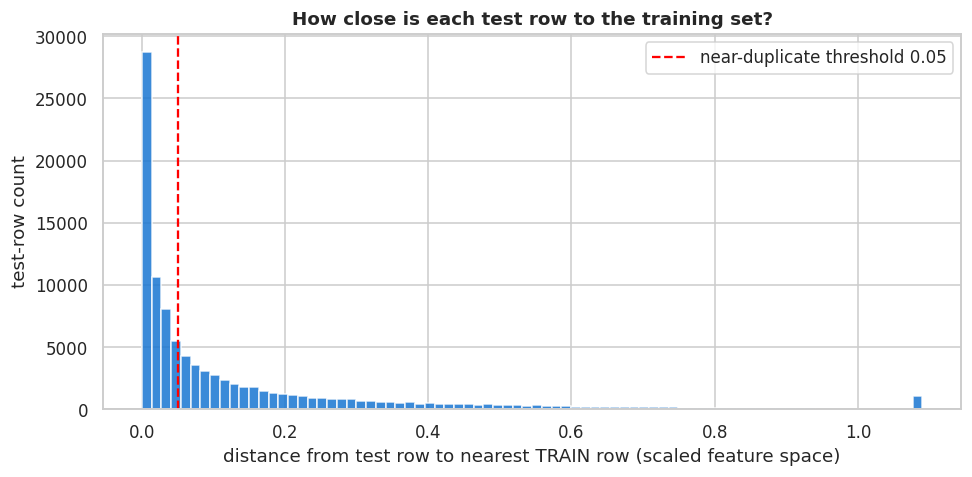

In [3]:
rng=np.random.RandomState(RANDOM_SEED)
# fit NN index on a sample of train for speed; sample test too (representative)
TR_SAMPLE=min(400_000, len(X_train)); TE_SAMPLE=min(100_000, len(X_test))
tr_idx=rng.choice(len(X_train), TR_SAMPLE, replace=False)
te_idx=rng.choice(len(X_test),  TE_SAMPLE, replace=False)
X_tr_s=X_train[tr_idx]; X_te_s=X_test[te_idx]

_log(''); _log('── SECTION 3 : NEAREST-NEIGHBOUR DISTANCES ────────────────')
t0=time.time()
nn=NearestNeighbors(n_neighbors=1, algorithm='auto', n_jobs=-1).fit(X_tr_s)
dist,_=nn.kneighbors(X_te_s)              # distance from each test row to nearest train row
dist=dist.ravel()
_log(f'  NN search on {TE_SAMPLE:,} test vs {TR_SAMPLE:,} train rows ({time.time()-t0:.1f}s)')

# how many test rows are essentially identical to a train row?
for thr in [1e-6, 1e-3, 1e-2, 0.05, 0.1]:
    frac=(dist<thr).mean()
    _log(f'    test rows with NN distance < {thr:<7}: {frac*100:6.2f}%')
_log('')
_log(f'  distance percentiles: p1={np.percentile(dist,1):.4f}  p25={np.percentile(dist,25):.4f}  '
     f'median={np.median(dist):.4f}  p75={np.percentile(dist,75):.4f}  p99={np.percentile(dist,99):.4f}')

fig,ax=plt.subplots(figsize=(9,4.5))
ax.hist(np.clip(dist,0,np.percentile(dist,99)),bins=80,color='#1976D2',alpha=0.85)
ax.axvline(0.05,ls='--',color='red',label='near-duplicate threshold 0.05')
ax.set_xlabel('distance from test row to nearest TRAIN row (scaled feature space)')
ax.set_ylabel('test-row count'); ax.set_title('How close is each test row to the training set?',fontweight='bold')
ax.legend(); plt.tight_layout(); _savefig('01_nn_distance_hist.png',fig); plt.show()

## 4. Does Accuracy Depend on Distance-to-Train?
The decisive test. Train a model, then bucket the test rows by their nearest-neighbour
distance and measure accuracy per bucket. A model that genuinely generalises keeps high
accuracy even for test rows that are *far* from any training example. A model living off
near-duplicates only succeeds in the near-zero bucket.


── SECTION 4 : ACCURACY vs DISTANCE-TO-TRAIN ──────────────
  (Q1 = test rows CLOSEST to train, Q5 = FARTHEST)
distance_bucket   dist_range     n  accuracy  macro_f1
             Q1  0.000-0.006 20000    0.9967    0.9905
             Q2  0.006-0.028 20000    0.9980    0.9607
             Q3  0.028-0.078 20000    0.9995    0.9846
             Q4  0.078-0.220 20000    0.9998    0.9726
             Q5 0.220-74.749 20000    0.9993    0.7771


,distance_bucket,dist_range,n,accuracy,macro_f1
0,Q1,0.000-0.006,20000,0.9967,0.9905
1,Q2,0.006-0.028,20000,0.9980,0.9607
2,Q3,0.028-0.078,20000,0.9995,0.9846
3,Q4,0.078-0.220,20000,0.9998,0.9726
4,Q5,0.220-74.749,20000,0.9993,0.7771


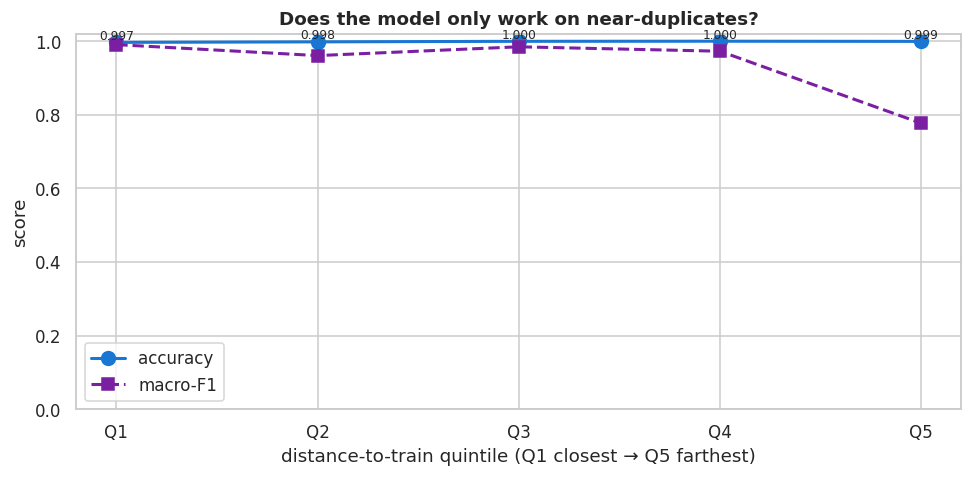

In [4]:
# train a quick RF on a train sample, predict on the SAME sampled test rows we have distances for
y_tr_mult=train_df['label_multi'].values[tr_idx]
y_te_mult_s=y_test_mult[te_idx]
clf=RandomForestClassifier(n_estimators=120,n_jobs=-1,class_weight='balanced',random_state=RANDOM_SEED)
clf.fit(X_tr_s,y_tr_mult)
pred=clf.predict(X_te_s)
correct=(pred==y_te_mult_s).astype(int)

# bucket by distance quintile
qs=np.quantile(dist,[0,0.2,0.4,0.6,0.8,1.0])
buckets=np.digitize(dist, qs[1:-1])
rows=[]
for b in range(5):
    m=buckets==b
    rows.append({'distance_bucket':f'Q{b+1}','dist_range':f'{qs[b]:.3f}-{qs[b+1]:.3f}',
                 'n':int(m.sum()),'accuracy':accuracy_score(y_te_mult_s[m],pred[m]),
                 'macro_f1':f1_score(y_te_mult_s[m],pred[m],average='macro')})
bdf=pd.DataFrame(rows)
_log(''); _log('── SECTION 4 : ACCURACY vs DISTANCE-TO-TRAIN ──────────────')
_log('  (Q1 = test rows CLOSEST to train, Q5 = FARTHEST)')
_log(bdf.to_string(index=False)); display(bdf)

fig,ax=plt.subplots(figsize=(9,4.5))
ax.plot(bdf['distance_bucket'],bdf['accuracy'],'o-',lw=2,markersize=9,color='#1976D2',label='accuracy')
ax.plot(bdf['distance_bucket'],bdf['macro_f1'],'s--',lw=2,markersize=8,color='#7B1FA2',label='macro-F1')
ax.set_ylim(0,1.02); ax.set_xlabel('distance-to-train quintile (Q1 closest → Q5 farthest)')
ax.set_ylabel('score'); ax.set_title('Does the model only work on near-duplicates?',fontweight='bold')
ax.legend()
for i,r in bdf.iterrows():
    ax.text(i,r['accuracy'],f'{r["accuracy"]:.3f}',ha='center',va='bottom',fontsize=8)
plt.tight_layout(); _savefig('02_accuracy_vs_distance.png',fig); plt.show()

## 5. Verdict

In [5]:
frac_dup=(dist<0.05).mean()
acc_near=bdf.loc[0,'accuracy']; acc_far=bdf.loc[4,'accuracy']
acc_gap=acc_near-acc_far

_log(''); _log('='*70); _log('SECTION 5 : VERDICT'); _log('='*70)
_log(f'  Test rows within 0.05 of a train row : {frac_dup*100:.2f}%')
_log(f'  Accuracy on CLOSEST quintile (Q1)    : {acc_near:.4f}')
_log(f'  Accuracy on FARTHEST quintile (Q5)   : {acc_far:.4f}')
_log(f'  Accuracy gap (near - far)            : {acc_gap:+.4f}')
_log('')
if frac_dup>0.5 and acc_gap>0.10:
    v=('LEAKAGE LIKELY — a large fraction of test rows are near-duplicates of train rows AND '
       'accuracy drops sharply for far rows. The high score is partly memorisation.')
elif acc_gap>0.10:
    v=('PARTIAL — accuracy is notably higher for rows near training data. Some inflation from '
       'near-duplicates; the score on genuinely novel flows is the Q5 number, not the headline.')
else:
    v=('CLEAN — accuracy is roughly flat across distance-to-train, and the model performs well '
       'even on test rows FAR from any training example. The high score reflects genuine '
       'generalisation, not near-duplicate memorisation.')
_log('  '+v); print('\nVerdict:',v)

bdf.to_csv(os.path.join(OUT_DIR,'near_duplicate_audit.csv'),index=False)
write_report(); print('Saved near_duplicate_audit.csv + report.')


SECTION 5 : VERDICT
  Test rows within 0.05 of a train row : 51.26%
  Accuracy on CLOSEST quintile (Q1)    : 0.9967
  Accuracy on FARTHEST quintile (Q5)   : 0.9993
  Accuracy gap (near - far)            : -0.0026

  CLEAN — accuracy is roughly flat across distance-to-train, and the model performs well even on test rows FAR from any training example. The high score reflects genuine generalisation, not near-duplicate memorisation.

Verdict: CLEAN — accuracy is roughly flat across distance-to-train, and the model performs well even on test rows FAR from any training example. The high score reflects genuine generalisation, not near-duplicate memorisation.
Report -> /kaggle/working/Audit_NearDuplicate_Report.txt
Saved near_duplicate_audit.csv + report.
